# 📊 Combined Portfolio Analysis in Python
This notebook covers both **basic** and **advanced** portfolio analysis techniques using Python.

**Topics:**
- Data download and cleaning
- Returns calculation and visualization
- Equal-weighted portfolio simulation
- Portfolio metrics (return, volatility, Sharpe)
- Value at Risk (VaR)
- Portfolio optimization (max Sharpe, min variance)
- Efficient frontier visualization

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

%matplotlib inline


In [14]:
# Download adjusted close prices from Yahoo Finance
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
start_date = '2020-01-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date, multi_level_index=False)['Close']
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-02,72.620834,94.900497,68.108368,153.042297,28.684000
2020-01-03,71.914833,93.748497,67.752075,151.136658,29.534000
2020-01-06,72.487869,95.143997,69.557945,151.527313,30.102667
2020-01-07,72.146927,95.343002,69.423584,150.145737,31.270666
2020-01-08,73.307503,94.598503,69.917732,152.537277,32.809334


In [15]:
# Calculate daily returns
daily_returns = data.pct_change().dropna()
daily_returns.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452,0.029633
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.019255
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.038801
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.049205
2020-01-09,0.021241,0.004799,0.010498,0.012493,-0.021945


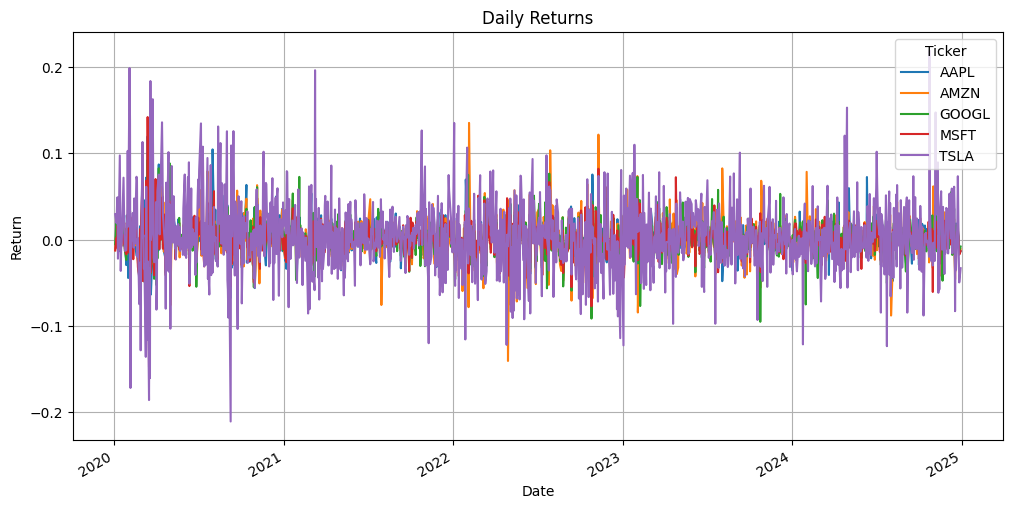

In [16]:
# Plot daily returns
daily_returns.plot(figsize=(12,6))
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()


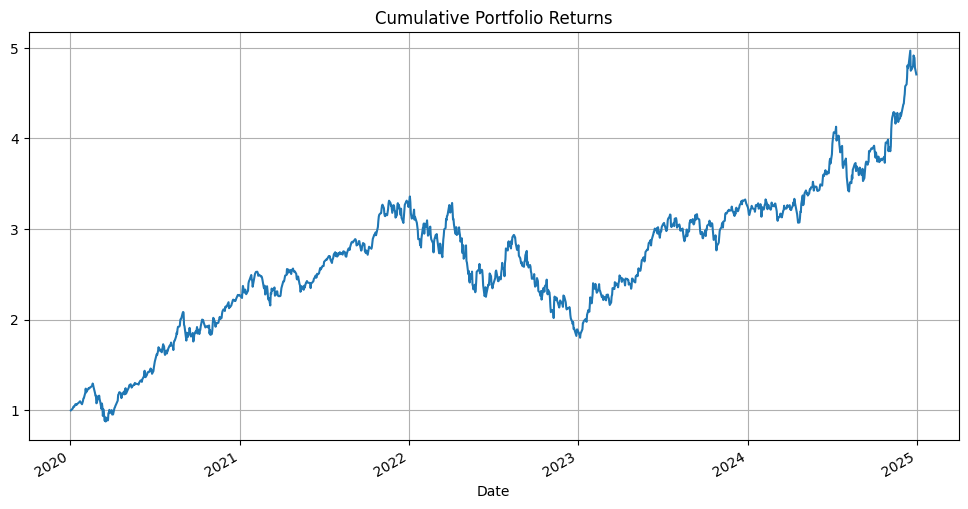

In [18]:
# Simulate an equal-weighted portfolio
weights = np.repeat(1/len(tickers), len(tickers))
portfolio_returns = (daily_returns * weights).sum(axis=1)
portfolio_cumulative = (1 + portfolio_returns).cumprod()

portfolio_cumulative.plot(figsize=(12,6), title="Cumulative Portfolio Returns")
plt.grid(True)
plt.show()


In [19]:
portfolio_cumulative.tail(1)

Date
2024-12-30    4.706913
dtype: float64

In [20]:
# Calculate basic performance metrics
annualized_return = portfolio_returns.mean() * 252
annualized_volatility = portfolio_returns.std() * np.sqrt(252)
sharpe_ratio = annualized_return / annualized_volatility

print(f"Annualized Return: {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Sharpe Ratio (Rf=0): {sharpe_ratio:.2f}")


Annualized Return: 36.14%
Annualized Volatility: 31.71%
Sharpe Ratio (Rf=0): 1.14


In [23]:
# Value at Risk (VaR) at 5% confidence
VaR = np.percentile(portfolio_returns, 5)
print(f"Value at Risk (5% level): {VaR:.2%}")


Value at Risk (5% level): -3.22%


In [24]:
# Portfolio optimization functions
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def negative_sharpe(weights, mean_returns, cov_matrix, rf=0):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - rf) / vol

def min_variance(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1] ** 2

def optimize_portfolio(mean_returns, cov_matrix, objective_func):
    n = len(mean_returns)
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    bounds = tuple((0, 1) for _ in range(n))
    result = minimize(objective_func, n * [1. / n], args=(mean_returns, cov_matrix), 
                      method='SLSQP', bounds=bounds, constraints=constraints)
    return result


In [25]:
# Optimize for max Sharpe and min volatility
mean_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

opt_sharpe = optimize_portfolio(mean_returns, cov_matrix, negative_sharpe)
opt_min_vol = optimize_portfolio(mean_returns, cov_matrix, min_variance)

print("Max Sharpe Weights:", opt_sharpe.x.round(2))
print("Min Volatility Weights:", opt_min_vol.x.round(2))


Max Sharpe Weights: [0.4  0.   0.19 0.   0.41]
Min Volatility Weights: [0.33 0.13 0.25 0.3  0.  ]


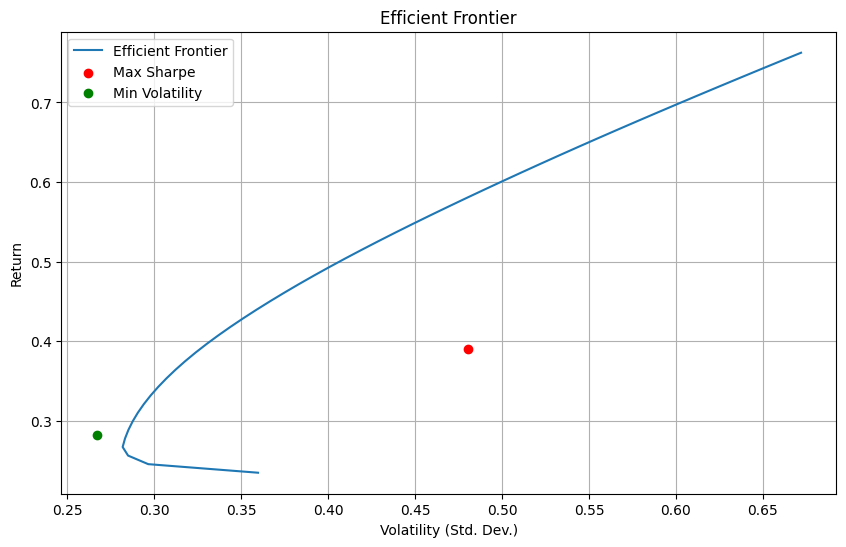

In [26]:
# Efficient frontier generation
def efficient_frontier(mean_returns, cov_matrix, points=50):
    frontier = {'returns': [], 'volatility': []}
    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), points)
    for ret in target_returns:
        constraints = (
            {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: np.dot(x, mean_returns) - ret}
        )
        bounds = tuple((0, 1) for _ in range(len(mean_returns)))
        result = minimize(min_variance, len(mean_returns) * [1. / len(mean_returns)],
                          args=(mean_returns, cov_matrix),
                          method='SLSQP', bounds=bounds, constraints=constraints)
        if result.success:
            p_ret, p_vol = portfolio_performance(result.x, mean_returns, cov_matrix)
            frontier['returns'].append(p_ret)
            frontier['volatility'].append(p_vol)
    return frontier

frontier = efficient_frontier(mean_returns, cov_matrix)

plt.figure(figsize=(10,6))
plt.plot(frontier['volatility'], frontier['returns'], label='Efficient Frontier')
plt.scatter(*portfolio_performance(opt_sharpe.x, mean_returns, cov_matrix), color='r', label='Max Sharpe')
plt.scatter(*portfolio_performance(opt_min_vol.x, mean_returns, cov_matrix), color='g', label='Min Volatility')
plt.xlabel('Volatility (Std. Dev.)')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()
